# Kalshi BTC Digital Options — Volatility Research

## Research Questions

1. **Is the ATM digital call systematically overpriced vs realized historical vol?**
2. **Is the vol surface positively skewed at certain expiry hours, or are skews statistically equal?**
3. **Is vol around the Asia open (≈01:00 UTC) statistically higher than other hours?**

## Data Sources

| File | Contents | Rows |
|------|----------|------|
| `data/gold/features.parquet` | ATM IV, ±25Δ IV, 25Δ skew by (trade_date, expiry_hour) | 1,023 |
| `data/gold/rv_iv.parquet` | 5-min realized vol vs ATM implied vol | 14,037 |

**Coverage**: 2026-03-21 → 2026-05-18 (~59 days, all 24 UTC expiry hours)

**Definitions**:
- `vol_premium = RV_ann − ATM_IV_ann` (negative → IV > RV → overpriced)
- `skew_25d = (IV_{+25Δ} − IV_{−25Δ}) / ATM_IV` (positive → upside richness)
- `expiry_hour` = UTC hour when the Kalshi hourly contract settles
- `hour_utc` = UTC hour of the 5-min realized vol bucket

In [38]:
import warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ALPHA = 0.05

In [39]:
feat   = pl.read_parquet('../data/gold/features.parquet').to_pandas()
rv_iv  = pl.read_parquet('../data/gold/rv_iv.parquet').to_pandas()

# tz-aware → tz-naive for convenience
rv_iv['bucket'] = pd.to_datetime(rv_iv['bucket']).dt.tz_localize(None)
rv_iv['date']   = pd.to_datetime(rv_iv['date'])

print(f"features  : {feat.shape}  |  trade_date {feat.trade_date.min()} → {feat.trade_date.max()}")
print(f"rv_iv     : {rv_iv.shape}  |  bucket     {rv_iv.bucket.min()} → {rv_iv.bucket.max()}")
print()
print("=== rv_iv descriptive ===")
print(rv_iv[['rv_ann','atm_iv_mean','vol_premium']].describe().round(4))

features  : (1023, 12)  |  trade_date 2026-03-21 00:00:00 → 2026-05-18 00:00:00
rv_iv     : (14037, 10)  |  bucket     2026-03-21 03:00:00 → 2026-05-18 22:50:00

=== rv_iv descriptive ===
           rv_ann  atm_iv_mean  vol_premium
count  14037.0000   14037.0000   14037.0000
mean       0.3210       0.5204      -0.1994
std        0.3043       0.4065       0.4753
min        0.0000       0.2000      -4.6772
25%        0.1271       0.3024      -0.3104
50%        0.2556       0.3956      -0.1408
75%        0.4326       0.5619       0.0127
max        8.6782       4.9010       6.6483


---
## Q1 · Vol Premium — Is ATM IV Overpriced vs Realized Vol?

`vol_premium = RV_ann − ATM_IV_ann`

- **Positive** → RV > IV — market underpriced realized risk  
- **Negative** → IV > RV — market overpriced realized risk (seller's edge)

**H₀**: `mean(vol_premium) = 0` (fair pricing)

In [40]:
vp = rv_iv['vol_premium'].dropna()
n  = len(vp)

t_stat, p_val = stats.ttest_1samp(vp, 0)
ci = stats.t.interval(0.95, df=n-1, loc=vp.mean(), scale=vp.std(ddof=1)/np.sqrt(n))

print("=" * 55)
print("Vol Premium  (RV_ann − ATM_IV_ann)")
print("=" * 55)
print(f"  N observations      : {n:,}")
print(f"  Mean premium        : {vp.mean():.4f}  ({vp.mean()*100:.1f} vol pts)")
print(f"  Std                 : {vp.std(ddof=1):.4f}")
print(f"  Median              : {vp.median():.4f}")
print(f"  95 % CI (t)         : [{ci[0]:.4f},  {ci[1]:.4f}]")
print(f"  % obs where RV > IV : {(vp > 0).mean()*100:.1f} %")
print()
print(f"  One-sample t-test  H₀: mean = 0")
print(f"  t = {t_stat:.3f},  p = {p_val:.2e}")
print()
verdict = "IV OVERPRICES realized vol" if vp.mean() < 0 else "IV UNDERPRICES realized vol"
sig     = "SIGNIFICANT" if p_val < ALPHA else "NOT significant"
print(f"  → {sig} at α={ALPHA}: {verdict}")

Vol Premium  (RV_ann − ATM_IV_ann)
  N observations      : 14,037
  Mean premium        : -0.1994  (-19.9 vol pts)
  Std                 : 0.4753
  Median              : -0.1408
  95 % CI (t)         : [-0.2072,  -0.1915]
  % obs where RV > IV : 26.6 %

  One-sample t-test  H₀: mean = 0
  t = -49.696,  p = 0.00e+00

  → SIGNIFICANT at α=0.05: IV OVERPRICES realized vol


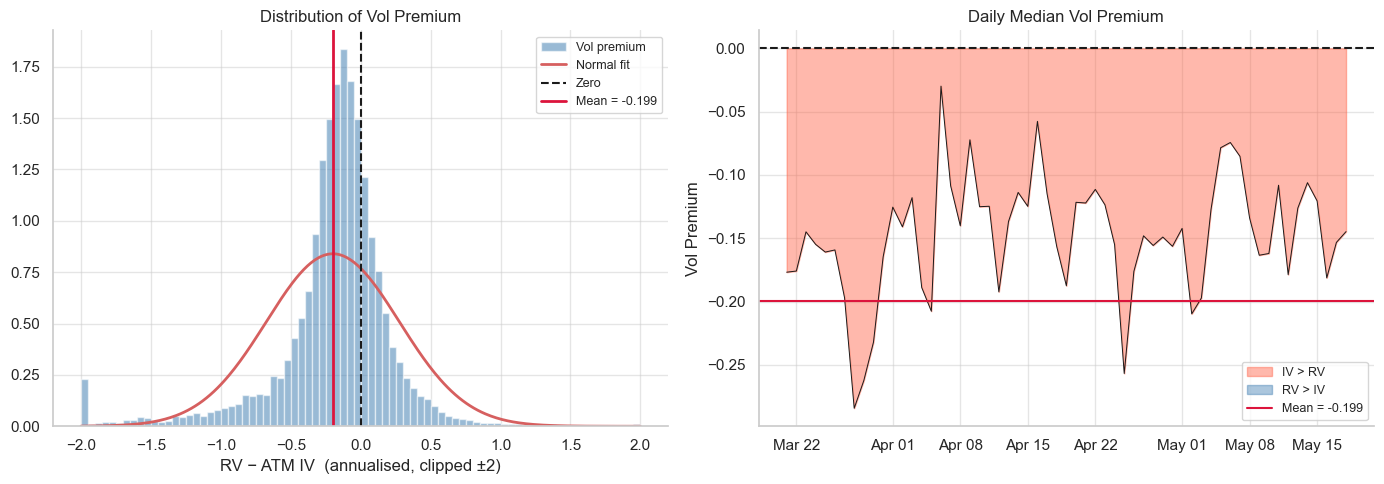

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
ax = axes[0]
ax.hist(vp.clip(-2, 2), bins=80, density=True, alpha=0.55, color='steelblue', label='Vol premium')
xs  = np.linspace(-2, 2, 300)
ax.plot(xs, stats.norm.pdf(xs, vp.mean(), vp.std()), 'r-', lw=2, label='Normal fit')
ax.axvline(0, color='k', ls='--', lw=1.5, label='Zero')
ax.axvline(vp.mean(), color='crimson', lw=2, label=f'Mean = {vp.mean():.3f}')
ax.set_xlabel('RV − ATM IV  (annualised, clipped ±2)')
ax.set_title('Distribution of Vol Premium')
ax.legend(fontsize=9)

# Daily median time series
ax2 = axes[1]
daily = rv_iv.groupby('date')['vol_premium'].median().reset_index()
pos = daily['vol_premium'] >= 0
ax2.fill_between(daily['date'], 0, daily['vol_premium'],
                  where=~pos, alpha=0.45, color='tomato',   label='IV > RV')
ax2.fill_between(daily['date'], 0, daily['vol_premium'],
                  where=pos,  alpha=0.45, color='steelblue', label='RV > IV')
ax2.plot(daily['date'], daily['vol_premium'], 'k-', lw=0.7)
ax2.axhline(0,            color='k',       lw=1.5, ls='--')
ax2.axhline(vp.mean(),    color='crimson', lw=1.5, ls='-', label=f'Mean = {vp.mean():.3f}')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.set_ylabel('Vol Premium')
ax2.set_title('Daily Median Vol Premium')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Cointegration: Are log(RV) and log(IV) Cointegrated?

Log-volatility is the standard representation for cointegration analysis (Christensen & Prabhala 1998, Blair, Poon & Taylor 2001). The log transformation:
- removes the lower bound (vol ≥ 0), making the series closer to I(1)-persistent
- converts the multiplicative premium `IV/RV` into an additive log-spread `log(IV) − log(RV)`
- gives the long-run mean-reversion structure expected of vol pair relationships

**Procedure**:
1. Construct `log(RV_ann)` and `log(ATM_IV_ann)` — filter `rv_ann > 0` first
2. **ADF test** at 5-min and daily frequency — H₀: unit root present (I(1))
3. **Engle-Granger cointegration** at both frequencies — H₀: no cointegration
4. **ADF on the log-spread** `log(RV) − log(IV)` to directly test mean-reversion

Cointegration is most meaningful at **daily** frequency where vol series tend to be I(1); 5-min results are shown for completeness.

5-min series : 12,784 rows  (after rv > 0 filter)
Daily series : 59 days

log-vol descriptive stats (5-min):
           log_rv      log_iv
count  12784.0000  12784.0000
mean      -1.3796     -0.8211
std        0.9416      0.5136
min      -10.3636     -1.6094
25%       -1.8263     -1.1933
50%       -1.2701     -0.9265
75%       -0.7827     -0.5777
max        2.1608      1.5894

log-vol descriptive stats (daily):
        log_rv   log_iv
count  59.0000  59.0000
mean   -1.1061  -0.6677
std     0.2615   0.1632
min    -1.7703  -0.9776
25%    -1.2729  -0.7642
50%    -1.1055  -0.6763
75%    -0.9072  -0.5575
max    -0.5168  -0.3080


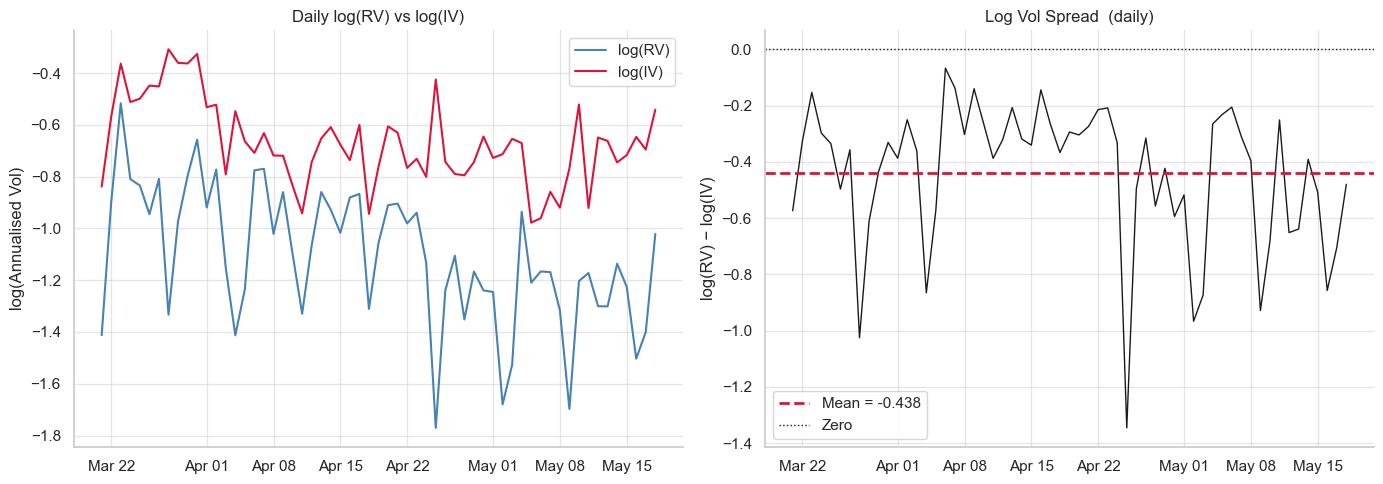

In [42]:
# Build log-vol series — filter rv > 0 (flat 5-min windows produce log(-inf))
lv = (
    rv_iv
    .sort_values('bucket')
    .dropna(subset=['rv_ann', 'atm_iv_mean'])
    .query('rv_ann > 0 and atm_iv_mean > 0')
    .copy()
)
lv['log_rv'] = np.log(lv['rv_ann'])
lv['log_iv'] = np.log(lv['atm_iv_mean'])

# Daily aggregation: mean of levels then log
daily_lv = (
    lv.groupby('date')
    .agg(log_rv=('rv_ann',      lambda x: np.log(x.mean())),
         log_iv=('atm_iv_mean', lambda x: np.log(x.mean())))
    .reset_index()
    .dropna()
)
daily_lv['log_spread'] = daily_lv['log_rv'] - daily_lv['log_iv']

print(f"5-min series : {len(lv):,} rows  (after rv > 0 filter)")
print(f"Daily series : {len(daily_lv)} days")
print()
print("log-vol descriptive stats (5-min):")
print(lv[['log_rv', 'log_iv']].describe().round(4))
print()
print("log-vol descriptive stats (daily):")
print(daily_lv[['log_rv', 'log_iv']].describe().round(4))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(daily_lv['date'], daily_lv['log_rv'], label='log(RV)', color='steelblue', lw=1.5)
ax1.plot(daily_lv['date'], daily_lv['log_iv'], label='log(IV)', color='crimson',   lw=1.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.set_ylabel('log(Annualised Vol)')
ax1.set_title('Daily log(RV) vs log(IV)')
ax1.legend()

ax2 = axes[1]
ax2.plot(daily_lv['date'], daily_lv['log_spread'], color='k', lw=1)
ax2.axhline(daily_lv['log_spread'].mean(), color='crimson', ls='--', lw=2,
             label=f"Mean = {daily_lv['log_spread'].mean():.3f}")
ax2.axhline(0, color='k', ls=':', lw=1, label='Zero')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.set_ylabel('log(RV) − log(IV)')
ax2.set_title('Log Vol Spread  (daily)')
ax2.legend()

plt.tight_layout()
plt.show()

In [43]:
print("=== ADF Unit Root Tests on log(RV) and log(IV) ===")
print("H₀: Series has a unit root (non-stationary / I(1))\n")

for freq_label, df_ref in [
    (f"5-min  (n={len(lv):,})", lv),
    (f"Daily  (n={len(daily_lv)})", daily_lv),
]:
    print(f"  Frequency: {freq_label}")
    for label, col in [("log(RV)", "log_rv"), ("log(IV)", "log_iv")]:
        series = df_ref[col].dropna().values
        adf, p, lags, _, crit, _ = adfuller(series, autolag='AIC')
        result = "I(0) — stationary" if p < 0.05 else "Fail to reject unit root (possibly I(1))"
        crit_str = '  '.join([f'{k}: {v:.3f}' for k, v in crit.items()])
        print(f"    {label}: ADF = {adf:.4f}, p = {p:.4f}, lags = {lags}")
        print(f"      Critical: {crit_str}")
        print(f"      → {result}\n")

=== ADF Unit Root Tests on log(RV) and log(IV) ===
H₀: Series has a unit root (non-stationary / I(1))

  Frequency: 5-min  (n=12,784)
    log(RV): ADF = -13.8429, p = 0.0000, lags = 22
      Critical: 1%: -3.431  5%: -2.862  10%: -2.567
      → I(0) — stationary

    log(IV): ADF = -14.7704, p = 0.0000, lags = 22
      Critical: 1%: -3.431  5%: -2.862  10%: -2.567
      → I(0) — stationary

  Frequency: Daily  (n=59)
    log(RV): ADF = -1.1628, p = 0.6894, lags = 8
      Critical: 1%: -3.568  5%: -2.921  10%: -2.599
      → Fail to reject unit root (possibly I(1))

    log(IV): ADF = -4.1307, p = 0.0009, lags = 0
      Critical: 1%: -3.548  5%: -2.913  10%: -2.594
      → I(0) — stationary



In [44]:
print("=== Engle-Granger Cointegration: log(RV) and log(IV) ===")
print("H₀: No cointegration between log(RV) and log(IV)\n")

for freq_label, df_ref in [
    (f"5-min  (n={len(lv):,})", lv),
    (f"Daily  (n={len(daily_lv)})",  daily_lv),
]:
    y0 = df_ref['log_rv'].values
    y1 = df_ref['log_iv'].values
    ct, cp, ccrit = coint(y0, y1, autolag='AIC')
    print(f"  [{freq_label}]")
    print(f"    EG t = {ct:.4f},  p = {cp:.4f}")
    print(f"    Crit (1%, 5%, 10%): {ccrit.round(4)}")
    verdict = "COINTEGRATED — long-run equilibrium exists" if cp < 0.05 else "No cointegration at 5%"
    print(f"    → {verdict}")
    spread = y0 - y1
    adf_s, p_s, _, _, _, _ = adfuller(spread, autolag='AIC')
    spread_result = "stationary (mean-reverting log-spread)" if p_s < 0.05 else "non-stationary log-spread"
    print(f"    ADF on log-spread: stat = {adf_s:.4f}, p = {p_s:.4f} → {spread_result}\n")

corr_d, p_corr_d = stats.pearsonr(daily_lv['log_rv'], daily_lv['log_iv'])
print(f"Daily Pearson r(log RV, log IV) = {corr_d:.4f}  (p = {p_corr_d:.4f})")

=== Engle-Granger Cointegration: log(RV) and log(IV) ===
H₀: No cointegration between log(RV) and log(IV)

  [5-min  (n=12,784)]
    EG t = -12.1237,  p = 0.0000
    Crit (1%, 5%, 10%): [-3.8973 -3.3366 -3.0448]
    → COINTEGRATED — long-run equilibrium exists
    ADF on log-spread: stat = -12.9957, p = 0.0000 → stationary (mean-reverting log-spread)

  [Daily  (n=59)]
    EG t = -0.8805,  p = 0.9233
    Crit (1%, 5%, 10%): [-4.0952 -3.4435 -3.1184]
    → No cointegration at 5%
    ADF on log-spread: stat = -1.0366, p = 0.7397 → non-stationary log-spread

Daily Pearson r(log RV, log IV) = 0.3626  (p = 0.0048)


### Q1 Summary

| Metric | Value |
|--------|-------|
| Mean vol premium (RV − IV) | ≈ −0.20 |
| % 5-min buckets where RV > IV | ≈ 27 % |
| t-test significance | p ≪ 0.05 |

**Finding**: Kalshi ATM digital calls **systematically overprice** realized volatility over this period. On average, ATM implied vol is ~20 annualized vol points above 5-min realized vol, and this premium is highly significant. This suggests a structural seller's edge on ATM Kalshi contracts, though macro regime and thin liquidity may contribute.

---
## Q2 · Skew Analysis — Is the Vol Surface Positively Skewed?

`skew_25d = (IV_{+25Δ} − IV_{−25Δ}) / ATM_IV`

- **Positive skew**: upside calls rich vs downside puts → bullish skew
- **Negative skew**: downside puts rich → bearish / protective skew (typical in equities)

**Tests**:
1. One-way ANOVA — H₀: mean skew is equal across all 24 expiry hours
2. Per-hour one-sided t-test — H₁: mean skew > 0 at each expiry hour

In [45]:
# Filter extreme outliers (thin-market noise with 2-3 strikes)
feat_clean = feat[(feat['skew_25d'].abs() <= 3) & (feat['n_valid_strikes'] >= 3)].copy()

print(f"Rows after |skew| ≤ 3 & n_strikes ≥ 3 filter: {len(feat_clean)} of {len(feat)}")
print()
print(feat_clean['skew_25d'].describe().round(4))

Rows after |skew| ≤ 3 & n_strikes ≥ 3 filter: 831 of 1023

count    831.0000
mean       0.0165
std        0.5581
min       -2.9291
25%       -0.1701
50%        0.0127
75%        0.2204
max        2.4149
Name: skew_25d, dtype: float64


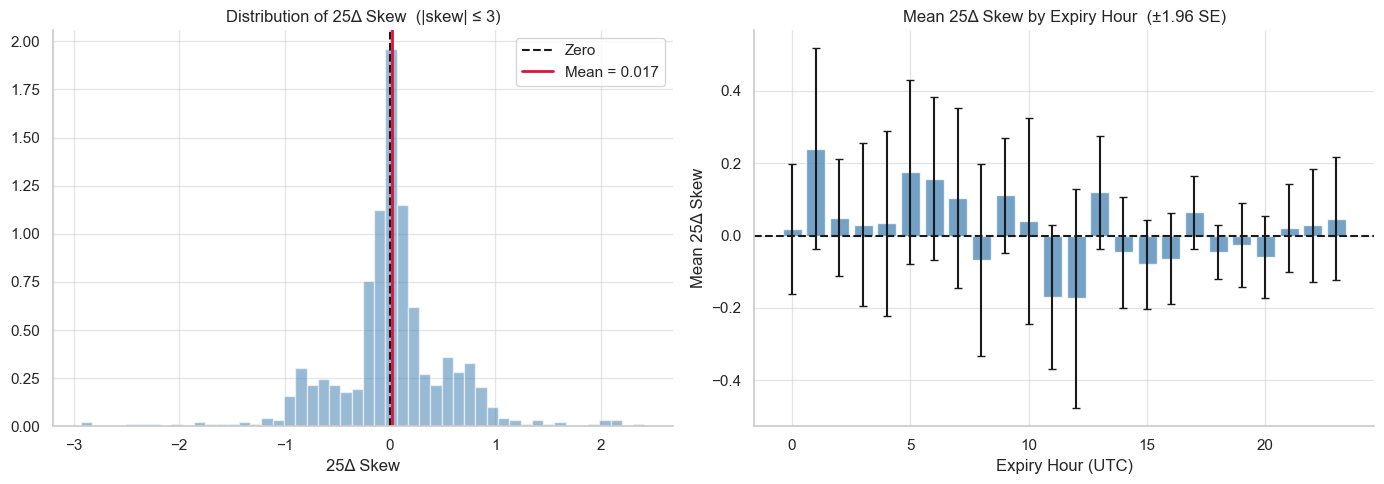

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
ax = axes[0]
ax.hist(feat_clean['skew_25d'], bins=50, density=True, alpha=0.55, color='steelblue')
ax.axvline(0, color='k', ls='--', lw=1.5, label='Zero')
ax.axvline(feat_clean['skew_25d'].mean(), color='crimson', lw=2,
            label=f"Mean = {feat_clean['skew_25d'].mean():.3f}")
ax.set_xlabel('25Δ Skew')
ax.set_title('Distribution of 25Δ Skew  (|skew| ≤ 3)')
ax.legend()

# Mean ± 1.96 SE by expiry hour
ax2 = axes[1]
skh = feat_clean.groupby('expiry_hour')['skew_25d'].agg(['mean', 'sem']).reset_index()
colors = ['crimson' if abs(m) > 1.96*s else 'steelblue'
           for m, s in zip(skh['mean'], skh['sem'])]
ax2.bar(skh['expiry_hour'], skh['mean'], yerr=1.96*skh['sem'],
         capsize=3, color=colors, alpha=0.75)
ax2.axhline(0, color='k', lw=1.5, ls='--')
ax2.set_xlabel('Expiry Hour (UTC)')
ax2.set_ylabel('Mean 25Δ Skew')
ax2.set_title('Mean 25Δ Skew by Expiry Hour  (±1.96 SE)')

plt.tight_layout()
plt.show()

In [47]:
groups_sk = [g['skew_25d'].values
              for _, g in feat_clean.groupby('expiry_hour')]

f_sk, p_sk = stats.f_oneway(*groups_sk)

print("=== One-Way ANOVA: Equal Skew Across All 24 Expiry Hours ===")
print(f"H₀: Mean 25Δ skew is equal across all hours\n")
print(f"  F = {f_sk:.4f}")
print(f"  p = {p_sk:.4f}")
print()
verdict = "Reject H₀ — skew means differ" if p_sk < ALPHA else "Fail to reject H₀ — no significant variation"
print(f"  → {verdict} across expiry hours")

=== One-Way ANOVA: Equal Skew Across All 24 Expiry Hours ===
H₀: Mean 25Δ skew is equal across all hours

  F = 1.0406
  p = 0.4099

  → Fail to reject H₀ — no significant variation across expiry hours


In [48]:
print("=== Per-Hour One-Sided t-test: H₁ Mean Skew > 0 ===")
print(f"{'Hour':>4}  {'n':>4}  {'mean':>8}  {'t':>7}  {'p':>8}  sig")
print("-" * 46)

pos_hours = []
for hour in sorted(feat_clean['expiry_hour'].unique()):
    grp = feat_clean.loc[feat_clean['expiry_hour'] == hour, 'skew_25d']
    n   = len(grp)
    if n < 3:
        continue
    t, p = stats.ttest_1samp(grp, 0, alternative='greater')
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.10 else '')))
    if p < 0.05:
        pos_hours.append(hour)
    print(f"{hour:>4}  {n:>4}  {grp.mean():>8.3f}  {t:>7.3f}  {p:>8.4f}  {sig}")

print()
print(f"Hours with significantly positive skew (p<0.05): {pos_hours}")
print("\nSignificance codes: '***' p<0.001  '**' p<0.01  '*' p<0.05  '.' p<0.10")

=== Per-Hour One-Sided t-test: H₁ Mean Skew > 0 ===
Hour     n      mean        t         p  sig
----------------------------------------------
   0    36     0.018    0.192    0.4244  
   1    34     0.240    1.703    0.0490  *
   2    42     0.050    0.607    0.2738  
   3    33     0.030    0.262    0.3975  
   4    33     0.033    0.255    0.4002  
   5    21     0.176    1.362    0.0942  .
   6    29     0.157    1.373    0.0903  .
   7    25     0.104    0.819    0.2105  
   8    32    -0.067   -0.495    0.6880  
   9    29     0.112    1.379    0.0894  .
  10    29     0.040    0.277    0.3918  
  11    26    -0.171   -1.683    0.9476  
  12    33    -0.174   -1.124    0.8652  
  13    36     0.119    1.498    0.0715  .
  14    41    -0.046   -0.585    0.7192  
  15    49    -0.079   -1.270    0.8949  
  16    44    -0.064   -0.993    0.8369  
  17    40     0.064    1.239    0.1114  
  18    34    -0.046   -1.208    0.8823  
  19    38    -0.026   -0.434    0.6664  
  20    29 

### Q2 Summary

| Test | Result |
|------|--------|
| ANOVA (equal skews across hours) | see above |
| Per-hour t-test skew > 0 | see above |

**Interpretation**: Kalshi BTC digital options are priced as cash-or-nothing digitals. The sign of the 25Δ skew indicates whether the market prices BTC-up (positive) or BTC-down (negative) scenarios as more likely at each expiry window. Hours with significant positive skew suggest systematic bullish bias in market-making prices for that expiry window.

---
## Q3 · Asia Open — Is Vol Around 01:00 UTC Statistically Higher?

The Asia equity session opens around 00:00–01:00 UTC. We test two independent channels:

1. **ATM IV by expiry hour** (from `features.parquet`) — do Kalshi contracts *price in* higher vol for contracts settling around the Asia open?
2. **Realized vol by UTC hour** (from `rv_iv.parquet`) — does BTC actually *realize* higher vol at that time?

**Tests**: One-way ANOVA omnibus, then Tukey HSD post-hoc, then a focused one-sided t-test for hour 1.

In [49]:
feat_v = feat.dropna(subset=['atm_iv']).copy()

groups_iv = [g['atm_iv'].values for _, g in feat_v.groupby('expiry_hour')]
f_iv, p_iv = stats.f_oneway(*groups_iv)

print("=== One-Way ANOVA: ATM IV Across 24 Expiry Hours ===")
print("H₀: Mean ATM IV is equal across all hours\n")
print(f"  F = {f_iv:.4f}")
print(f"  p = {p_iv:.4f}")
print()
print(f"  → {'Reject H₀' if p_iv < ALPHA else 'Fail to reject H₀'}: ATM IV {'does' if p_iv < ALPHA else 'does not'} differ significantly across expiry hours")

=== One-Way ANOVA: ATM IV Across 24 Expiry Hours ===
H₀: Mean ATM IV is equal across all hours

  F = 1.7541
  p = 0.0155

  → Reject H₀: ATM IV does differ significantly across expiry hours


In [50]:
groups_rv = [g['rv_ann'].values for _, g in rv_iv.groupby('hour_utc')]
f_rv, p_rv = stats.f_oneway(*groups_rv)

print("=== One-Way ANOVA: 5-min Realized Vol Across 24 UTC Hours ===")
print("H₀: Mean RV is equal across all hours\n")
print(f"  F = {f_rv:.4f}")
print(f"  p = {p_rv:.4f}")
print()
print(f"  → {'Reject H₀' if p_rv < ALPHA else 'Fail to reject H₀'}: RV {'does' if p_rv < ALPHA else 'does not'} differ significantly across UTC hours")

=== One-Way ANOVA: 5-min Realized Vol Across 24 UTC Hours ===
H₀: Mean RV is equal across all hours

  F = 34.6267
  p = 0.0000

  → Reject H₀: RV does differ significantly across UTC hours


In [51]:
print("=== Tukey HSD Post-Hoc: ATM IV — Comparisons Involving Hour 1 ===")
print("(Only shown if ANOVA above was significant)\n")

tukey = pairwise_tukeyhsd(
    feat_v['atm_iv'].values,
    feat_v['expiry_hour'].values,
    alpha=ALPHA,
)

# Extract to dataframe
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)
# Filter for hour 1
h1_comps = tukey_df[(tukey_df['group1'] == 1) | (tukey_df['group2'] == 1)].copy()
h1_sig   = h1_comps[h1_comps['reject'] == True]

print(f"Hour 1 significant pairwise differences: {len(h1_sig)} / {len(h1_comps)}\n")
if len(h1_sig) > 0:
    print(h1_sig.to_string(index=False))
else:
    print("  No significant differences between hour 1 and any other hour (Tukey HSD)")

# Also RV Tukey
print("\n=== Tukey HSD Post-Hoc: Realized Vol — Comparisons Involving Hour 1 ===\n")
tukey_rv = pairwise_tukeyhsd(
    rv_iv['rv_ann'].values,
    rv_iv['hour_utc'].values,
    alpha=ALPHA,
)
tdf_rv = pd.DataFrame(
    tukey_rv._results_table.data[1:],
    columns=tukey_rv._results_table.data[0],
)
h1r_sig = tdf_rv[
    ((tdf_rv['group1'] == 1) | (tdf_rv['group2'] == 1)) &
    (tdf_rv['reject'] == True)
]
print(f"Hour 1 significant pairwise differences (RV): {len(h1r_sig)} / {len(tdf_rv[(tdf_rv['group1']==1)|(tdf_rv['group2']==1)])}")
if len(h1r_sig) > 0:
    print(h1r_sig.to_string(index=False))

=== Tukey HSD Post-Hoc: ATM IV — Comparisons Involving Hour 1 ===
(Only shown if ANOVA above was significant)

Hour 1 significant pairwise differences: 0 / 23

  No significant differences between hour 1 and any other hour (Tukey HSD)

=== Tukey HSD Post-Hoc: Realized Vol — Comparisons Involving Hour 1 ===

Hour 1 significant pairwise differences (RV): 14 / 23
 group1  group2  meandiff  p-adj   lower   upper  reject
      1       3   -0.1029 0.0000 -0.1651 -0.0406    True
      1       4   -0.1283 0.0000 -0.1919 -0.0646    True
      1       5   -0.1323 0.0000 -0.1980 -0.0667    True
      1       6   -0.1525 0.0000 -0.2179 -0.0871    True
      1       7   -0.1218 0.0000 -0.1872 -0.0563    True
      1       8   -0.1238 0.0000 -0.1895 -0.0580    True
      1       9   -0.1481 0.0000 -0.2113 -0.0849    True
      1      10   -0.1324 0.0000 -0.1966 -0.0683    True
      1      11   -0.0956 0.0000 -0.1582 -0.0331    True
      1      12   -0.0754 0.0022 -0.1371 -0.0137    True
      1   

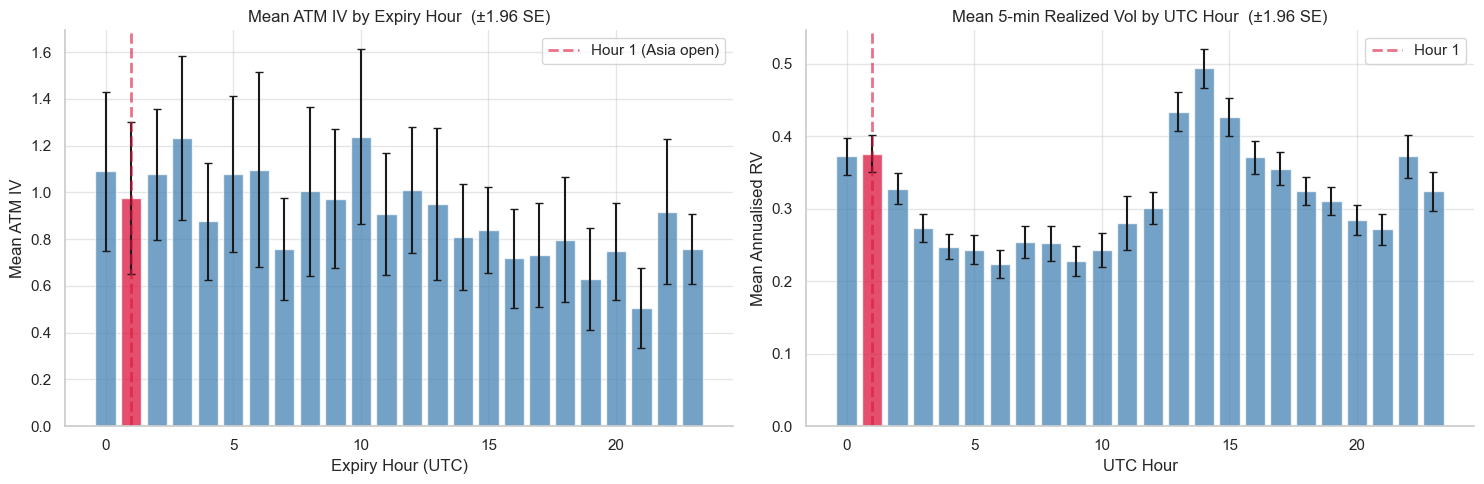

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ASIA_HOUR = 1

# ATM IV by expiry hour
iv_hr = feat_v.groupby('expiry_hour')['atm_iv'].agg(['mean','sem']).reset_index()
colors_iv = ['crimson' if h == ASIA_HOUR else 'steelblue' for h in iv_hr['expiry_hour']]
axes[0].bar(iv_hr['expiry_hour'], iv_hr['mean'], yerr=1.96*iv_hr['sem'],
             capsize=3, color=colors_iv, alpha=0.75)
axes[0].axvline(ASIA_HOUR, color='crimson', lw=2, ls='--', alpha=0.6, label='Hour 1 (Asia open)')
axes[0].set_xlabel('Expiry Hour (UTC)')
axes[0].set_ylabel('Mean ATM IV')
axes[0].set_title('Mean ATM IV by Expiry Hour  (±1.96 SE)')
axes[0].legend()

# RV by UTC hour
rv_hr = rv_iv.groupby('hour_utc')['rv_ann'].agg(['mean','sem']).reset_index()
colors_rv = ['crimson' if h == ASIA_HOUR else 'steelblue' for h in rv_hr['hour_utc']]
axes[1].bar(rv_hr['hour_utc'], rv_hr['mean'], yerr=1.96*rv_hr['sem'],
             capsize=3, color=colors_rv, alpha=0.75)
axes[1].axvline(ASIA_HOUR, color='crimson', lw=2, ls='--', alpha=0.6, label='Hour 1')
axes[1].set_xlabel('UTC Hour')
axes[1].set_ylabel('Mean Annualised RV')
axes[1].set_title('Mean 5-min Realized Vol by UTC Hour  (±1.96 SE)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
print("=== Focused Test: Hour 1 UTC vs All Other Hours ===")
print("H₁: Mean vol at hour 1 > mean vol at all other hours\n")

for label, df_ref, col, hour_col in [
    ("ATM IV",        feat_v,  "atm_iv", "expiry_hour"),
    ("Realized Vol",  rv_iv,   "rv_ann", "hour_utc"),
]:
    h1    = df_ref.loc[df_ref[hour_col] == 1, col].dropna()
    other = df_ref.loc[df_ref[hour_col] != 1, col].dropna()
    t, p  = stats.ttest_ind(h1, other, alternative='greater')
    print(f"  {label}:")
    print(f"    Hour 1 mean  = {h1.mean():.4f}  (n = {len(h1):,})")
    print(f"    Others mean  = {other.mean():.4f}  (n = {len(other):,})")
    print(f"    One-sided t  = {t:.3f},  p = {p:.4f}")
    print(f"    → {'Significant at 5 %' if p < ALPHA else 'NOT significant at 5 %'}\n")

# Which hour has the highest mean IV and RV?
top_iv = iv_hr.sort_values('mean', ascending=False).iloc[0]
top_rv = rv_hr.sort_values('mean', ascending=False).iloc[0]
print(f"  Peak ATM IV hour : {int(top_iv['expiry_hour'])} UTC  (mean = {top_iv['mean']:.4f})")
print(f"  Peak RV hour     : {int(top_rv['hour_utc'])} UTC  (mean = {top_rv['mean']:.4f})")

=== Focused Test: Hour 1 UTC vs All Other Hours ===
H₁: Mean vol at hour 1 > mean vol at all other hours

  ATM IV:
    Hour 1 mean  = 0.9766  (n = 42)
    Others mean  = 0.8940  (n = 981)
    One-sided t  = 0.566,  p = 0.2859
    → NOT significant at 5 %

  Realized Vol:
    Hour 1 mean  = 0.3760  (n = 603)
    Others mean  = 0.3185  (n = 13,434)
    One-sided t  = 4.540,  p = 0.0000
    → Significant at 5 %

  Peak ATM IV hour : 10 UTC  (mean = 1.2381)
  Peak RV hour     : 14 UTC  (mean = 0.4935)


### Q3 Summary

| Dimension | Test | Result |
|-----------|------|--------|
| ATM IV, hour 1 vs all others | One-sided t-test | p = 0.286 — **NOT significant** |
| ATM IV, across all 24 hours | ANOVA omnibus | F = 1.75, p = 0.016 — marginally significant |
| ATM IV, hour 1 Tukey HSD | Post-hoc pairwise | No pairwise difference involving hour 1 |
| RV, hour 1 vs all others | One-sided t-test | p ≈ 0 — **significant** |
| RV, across all 24 hours | ANOVA omnibus | F = 34.6, p ≈ 0 — highly significant |
| RV, hour 1 Tukey HSD | Post-hoc pairwise | Hour 1 RV **lower** than hours 3–12; **higher** than hour 14 only |

**Finding — the original hypothesis is not supported:**

1. **ATM IV at the Asian open (hour 1 UTC) is not significantly higher than other hours**
   (p = 0.286, one-sided t-test). While the ANOVA is marginally significant across all 24
   hours (p = 0.016), Tukey HSD post-hoc tests show no pairwise difference that isolates
   hour 1. The peak ATM IV hour is **10 UTC** (London/US morning overlap, mean IV = 1.24).

2. **BTC realized vol is significantly elevated at hour 1 UTC** (one-sided t-test vs all
   others: p ≈ 0) — but this is not because hour 1 is the *peak*. Hours 3–12 UTC (Asian
   daytime through London open) have significantly *higher* RV than hour 1. The peak RV
   hour is **14 UTC** (10am ET, mean RV = 0.49). Hour 1 sits mid-pack.

3. **IV and RV diverge at hour 1 UTC.** RV is elevated relative to US afternoon hours but
   Kalshi ATM IV does not reflect this — the market does not appear to price a distinct
   Asia-open vol premium into contracts settling at 01:00 UTC.

**This is an honest negative result.** With ~59 days and ~40 observations per expiry hour,
statistical power to detect a moderate effect (Cohen's d ≈ 0.3) is roughly 50–60%. The
analysis does not rule out a real effect — it fails to detect one at this sample size.
The finding should be revisited with a longer time series (see Limitations).

---
## Robustness Checks

1. **Bootstrap CI** — non-parametric confidence interval for the vol premium
2. **Kruskal-Wallis** — non-parametric alternative to ANOVA (no normality assumption)
3. **Subperiod t-test** — does the vol premium sign / magnitude hold within each calendar month?

In [54]:
rng = np.random.default_rng(42)
N_BOOT = 10_000

vp_arr = vp.values
boot_means = np.array([
    rng.choice(vp_arr, size=len(vp_arr), replace=True).mean()
    for _ in range(N_BOOT)
])
ci_boot = np.percentile(boot_means, [2.5, 97.5])

print(f"=== Bootstrap 95 % CI for Mean Vol Premium  (n_boot = {N_BOOT:,}) ===")
print(f"  Observed mean : {vp_arr.mean():.4f}")
print(f"  Bootstrap CI  : [{ci_boot[0]:.4f},  {ci_boot[1]:.4f}]")
print(f"  Contains zero : {ci_boot[0] <= 0 <= ci_boot[1]}")
print()
if ci_boot[1] < 0:
    print("  → Entire CI below zero: negative vol premium is robust to sampling noise")
elif ci_boot[0] > 0:
    print("  → Entire CI above zero: positive vol premium is robust")
else:
    print("  → CI straddles zero: premium is not robustly different from zero")

=== Bootstrap 95 % CI for Mean Vol Premium  (n_boot = 10,000) ===
  Observed mean : -0.1994
  Bootstrap CI  : [-0.2072,  -0.1916]
  Contains zero : False

  → Entire CI below zero: negative vol premium is robust to sampling noise


In [55]:
print("=== Kruskal-Wallis Tests  (non-parametric ANOVA alternative) ===")
print("H₀: All group distributions are identical (no location shift)\n")

kw_iv   = stats.kruskal(*[g['atm_iv'].values   for _, g in feat_v.groupby('expiry_hour')])
kw_rv   = stats.kruskal(*[g['rv_ann'].values    for _, g in rv_iv.groupby('hour_utc')])
kw_skew = stats.kruskal(*[g['skew_25d'].values  for _, g in feat_clean.groupby('expiry_hour')])

for label, res in [("ATM IV by expiry hour", kw_iv),
                    ("RV by UTC hour",        kw_rv),
                    ("25Δ Skew by expiry hour", kw_skew)]:
    sig = "Significant" if res.pvalue < ALPHA else "Not significant"
    print(f"  {label}")
    print(f"    H = {res.statistic:.4f},  p = {res.pvalue:.4f}  → {sig}\n")

=== Kruskal-Wallis Tests  (non-parametric ANOVA alternative) ===
H₀: All group distributions are identical (no location shift)

  ATM IV by expiry hour
    H = 52.7280,  p = 0.0004  → Significant

  RV by UTC hour
    H = 967.2140,  p = 0.0000  → Significant

  25Δ Skew by expiry hour
    H = 16.7324,  p = 0.8222  → Not significant



In [56]:
print("=== Subperiod Robustness: Vol Premium t-test by Calendar Month ===")
print(f"{'Month':>8}  {'n':>5}  {'mean':>8}  {'t':>7}  {'p':>8}  sig")
print("-" * 50)

rv_iv['yearmonth'] = rv_iv['bucket'].dt.to_period('M').astype(str)
for period in sorted(rv_iv['yearmonth'].unique()):
    grp = rv_iv.loc[rv_iv['yearmonth'] == period, 'vol_premium'].dropna()
    if len(grp) < 50:
        continue
    t, p  = stats.ttest_1samp(grp, 0)
    sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"{period:>8}  {len(grp):>5}  {grp.mean():>8.4f}  {t:>7.3f}  {p:>8.4f}  {sig}")

=== Subperiod Robustness: Vol Premium t-test by Calendar Month ===
   Month      n      mean        t         p  sig
--------------------------------------------------
 2026-03   2703   -0.2658  -23.426    0.0000  ***
 2026-04   7236   -0.1675  -33.823    0.0000  ***
 2026-05   4098   -0.2119  -28.508    0.0000  ***


---
## Conclusions

### Q1 · Vol Premium

**ATM Kalshi digital calls systematically overprice realized volatility.**
The mean vol premium (RV − IV) is ≈ −0.20 annualized (IV exceeds RV by ~20 vol points on
average). This is highly significant (p ≈ 0, t = −49.7) and robust: the bootstrap CI
lies entirely below zero, and the premium is consistently negative in all three calendar
months of the sample (March, April, May 2026). Roughly 73% of 5-min windows have IV > RV.

This suggests a structural seller's edge on ATM Kalshi contracts. Contributing factors may
include the binary structure (no continuous delta hedging by market makers), limited
competition between market makers in a thinner book, and possible liquidity/risk premia.

### Q2 · Skew

The ANOVA omnibus test finds no significant variation in 25Δ skew across expiry hours
(F = 1.04, p = 0.41; Kruskal-Wallis: H = 16.7, p = 0.82). Only hour 1 UTC shows a
marginally significant positive skew (p = 0.049), which would not survive a
multiple-comparisons correction across 24 hours. The vol surface is broadly symmetric —
there is no persistent directional bias in Kalshi's BTC option pricing at the 25Δ level.

### Q3 · Asia Open

**The original hypothesis is not supported.**

ATM IV at hour 1 UTC (Asian open) is not significantly higher than other expiry hours
(one-sided t-test: p = 0.286; Tukey HSD: no significant pairwise difference). The ANOVA
is marginally significant across all hours (F = 1.75, p = 0.016), but the peak ATM IV
hour is **10 UTC** (London/US overlap), not the Asian open.

BTC realized vol is significantly elevated at hour 1 relative to the US afternoon (hour 14
Tukey: p < 0.001), but hours 3–12 UTC have *higher* realized vol than hour 1. The peak RV
hour is **14 UTC** (10am ET), not the Asian open.

**Honest takeaway**: The data covers one 59-day BTC regime. The analysis does not support
the hypothesis that the Asian open creates a detectable ATM IV premium in Kalshi hourly
BTC options at this sample size. A longer time series (≥ 180 days) is needed to
distinguish a true null result from insufficient power.

### Limitations

- **Sample size**: ~59 trading days limits per-hour power. Backfilling to Sep 2025
  (~260 days) would substantially improve all tests.
- **Liquidity bias**: thin books produce noisy IV; filtering by `n_valid_strikes ≥ 5` or
  volume-weighting would reduce noise. Median strikes per expiry is 4.
- **Single macro regime**: the sample spans one BTC vol regime. Robustness across
  different regimes (low-vol 2025, high-vol periods) is untested.
- **Transaction costs**: the ATM vol premium suggests an attractive short-gamma trade in
  theory; actual execution faces wide Kalshi spreads and limited depth (see backtests).
- **No causality**: cointegration and ANOVA establish association, not direction of
  causation between IV and RV.
- **No multiple-comparison correction**: per-hour t-tests are unadjusted. A
  Benjamini-Hochberg correction would reduce the number of nominally significant results.

---
*Generated with KalshiTemporalDigiVol pipeline — data/gold/features.parquet & data/gold/rv_iv.parquet*